In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd

In [2]:
timeflag =False
atomflag=False
atoms = 100
count = 0
timelist = []
atomlist = []
tempatomlist=[]
tempatomlistx=[]
tempatomlisty=[]
atomlistx = []
atomlisty = []
with open('traj.txt', 'r') as file:
    for line in file:
        if "ITEM" in line:
            if "ITEM: TIMESTEP" in line:
                count += 1
                timeflag = True
                atomflag=False
                atomlist.append(tempatomlist)
                atomlistx.append(tempatomlistx)
                atomlisty.append(tempatomlisty)

                tempatomlist=[]
                tempatomlistx=[]
                tempatomlisty=[]

            elif "ITEM: ATOMS" in line:
                atomflag = True
                timeflag=False
            else:
                timeflag = False
                atomflag = False
        if timeflag and ("ITEM" not in line):
            timelist.append(float(line.strip()))
        if atomflag and ("ITEM" not in line):
            tempatomlist.append(float(line.strip().split(" ")[-1]))
            tempatomlistx.append(float(line.strip().split(" ")[-3]))
            tempatomlisty.append(float(line.strip().split(" ")[-2]))

            count += 1
atomlist.append(tempatomlist)
atomlistx.append(tempatomlistx)
atomlisty.append(tempatomlisty)


atomlist.pop(0)
atomlistx.pop(0)
atomlisty.pop(0)
timearr = np.array(timelist)
atomarr = np.array(atomlist)
atomarrx = np.array(atomlistx)
atomarry = np.array(atomlisty)
timearr *= 2.0e-16
print(timearr)
print(atomarr[:,0])


[0.000e+00 2.000e-13 4.000e-13 ... 2.088e-10 2.090e-10 2.092e-10]
[ -189576.  -189576. 10000000. ...  3035410.  2412440.  4664570.]


365457.7364660066


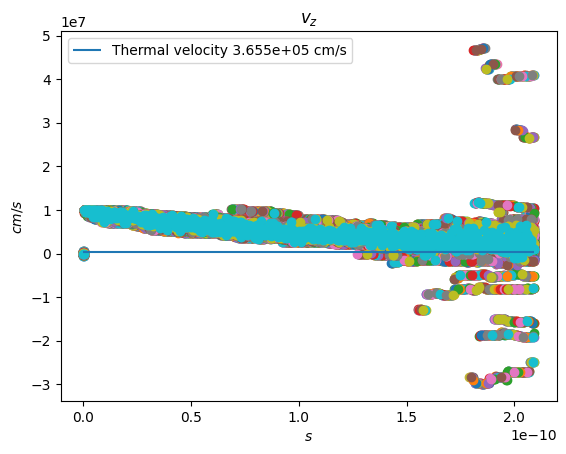

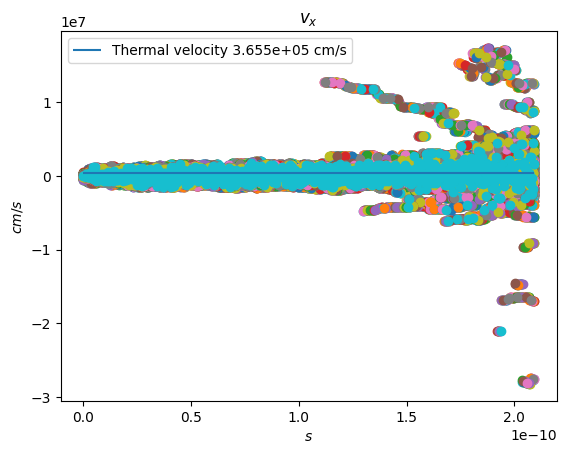

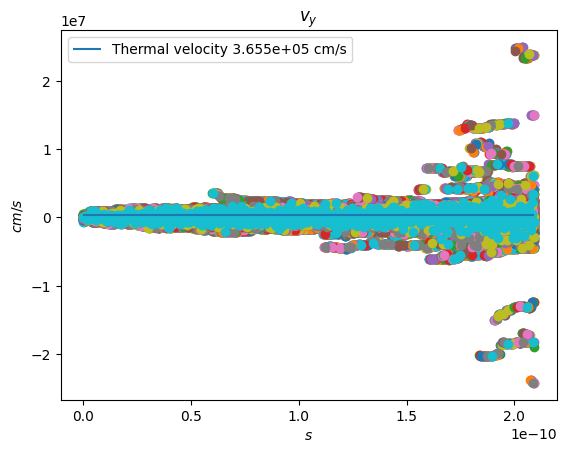

In [3]:
Temp = 15000
kb = 1.38e-23
NA = 6.022e23
thermvel = 100*((3*kb*Temp/(0.028/NA))**0.5)
print(thermvel)
plt.figure()
for i in range(atoms):
    plt.scatter(timearr,atomarr[:,i])
plt.hlines(thermvel,np.min(timearr),np.max(timearr),label="Thermal velocity {:.3e} cm/s".format(thermvel))
plt.legend()
plt.title(r"$v_z$")
plt.ylabel(r"$cm/s$")
plt.xlabel(r"$s$")
plt.show()
plt.figure()
for i in range(atoms):
    plt.scatter(timearr,atomarrx[:,i])
plt.title(r"$v_x$")
plt.ylabel(r"$cm/s$")
plt.hlines(thermvel,np.min(timearr),np.max(timearr),label="Thermal velocity {:.3e} cm/s".format(thermvel))
plt.legend()
plt.xlabel(r"$s$")
plt.show()
plt.figure()
for i in range(atoms):
    plt.scatter(timearr,atomarry[:,i])
plt.title(r"$v_y$")
plt.hlines(thermvel,np.min(timearr),np.max(timearr),label="Thermal velocity {:.3e} cm/s".format(thermvel))
plt.legend()
plt.ylabel(r"$cm/s$")
plt.xlabel(r"$s$")
plt.show()

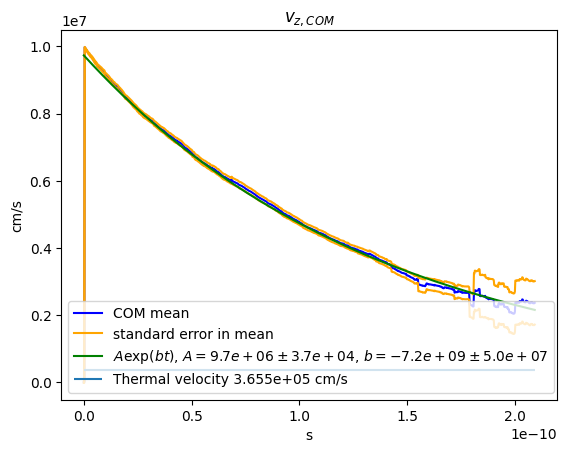

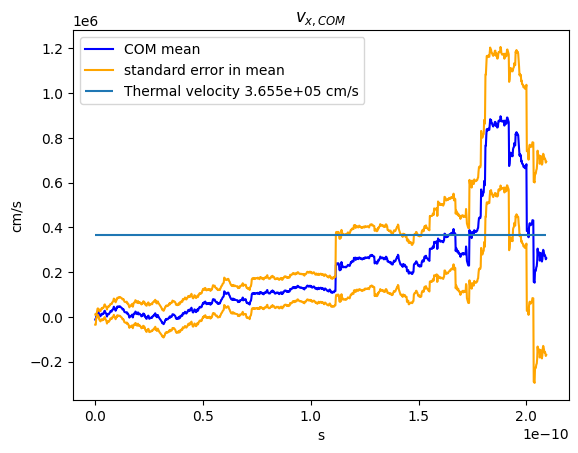

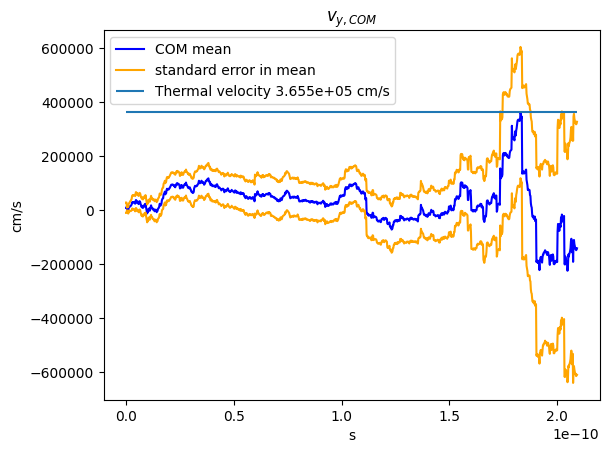

In [4]:
from scipy.optimize import curve_fit
res = np.copy(atomarr)
resx = np.copy(atomarrx)
resy = np.copy(atomarry)
meanarr = np.zeros((len(timearr),3))
stdmeanarr = np.zeros( (len(timearr),3))
for i in range(len(timearr)):
    meanarr[i,0] = np.mean(resx[i,:])
    meanarr[i,1] = np.mean(resy[i,:])
    meanarr[i,2] = np.mean(res[i,:])
    stdmeanarr[i,0] = np.std(resx[i,:])
    stdmeanarr[i,1] = np.std(resy[i,:])
    stdmeanarr[i,2] = np.std(res[i,:])

    res[i,:] -= np.mean(res[i,:])
    resx[i,:] -= np.mean(resx[i,:])
    resy[i,:] -= np.mean(resy[i,:])
stdmeanarr /= np.sqrt(atoms)

bestfit,pcov = curve_fit(lambda t,a,b: a*np.exp(b*t),  timearr,  meanarr[:,2],  p0=(1e7, -0.1))
besta = bestfit[0]
bestb = bestfit[1]
aerr = np.sqrt(np.diag(pcov))[0]
berr = np.sqrt(np.diag(pcov))[1]

plt.figure()
plt.plot(timearr,meanarr[:,2],label="COM mean",color="blue")
plt.plot(timearr,meanarr[:,2]+stdmeanarr[:,2],label="standard error in mean",color="orange")
plt.plot(timearr,meanarr[:,2]-stdmeanarr[:,2],color="orange")
plt.plot(timearr,besta*np.exp(bestb*timearr),color="green",label=r'$A\exp(bt)$, $A={:.1e}\pm{:.1e}$, $b={:.1e}\pm {:.1e}$'.format(besta,aerr,bestb,berr))
plt.legend()
plt.title(r"$v_{z,COM}$")
plt.ylabel(r"cm/s")
plt.hlines(thermvel,np.min(timearr),np.max(timearr),label="Thermal velocity {:.3e} cm/s".format(thermvel))
plt.legend()
plt.xlabel(r"s")
plt.show()
plt.figure()
plt.plot(timearr,meanarr[:,0],label="COM mean",color="blue")
plt.plot(timearr,meanarr[:,0]+stdmeanarr[:,0],label="standard error in mean",color="orange")
plt.plot(timearr,meanarr[:,0]-stdmeanarr[:,0],color="orange")
plt.title(r"$v_{x,COM}$")
plt.hlines(thermvel,np.min(timearr),np.max(timearr),label="Thermal velocity {:.3e} cm/s".format(thermvel))
plt.legend()
plt.ylabel(r"cm/s")
plt.xlabel(r"s")
plt.show()
plt.figure()
plt.plot(timearr,meanarr[:,1],label="COM mean",color="blue")
plt.plot(timearr,meanarr[:,1]+stdmeanarr[:,1],label="standard error in mean",color="orange")
plt.plot(timearr,meanarr[:,1]-stdmeanarr[:,1],color="orange")
plt.title(r"$v_{y,COM}$")
plt.ylabel(r"cm/s")
plt.xlabel(r"s")
plt.hlines(thermvel,np.min(timearr),np.max(timearr),label="Thermal velocity {:.3e} cm/s".format(thermvel))
plt.legend()
plt.show()

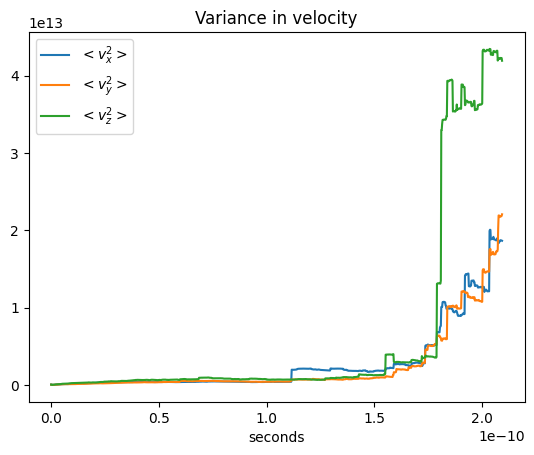

In [5]:
variancearr = np.zeros((len(timearr),3))
for i in range(len(timearr)):
    variancearr[i,0] = np.var(atomarrx[i,:])
    variancearr[i,1] = np.var(atomarry[i,:])
    variancearr[i,2] = np.var(atomarr[i,:])


plt.figure()
plt.title("Variance in velocity")
plt.plot(timearr,variancearr[:,0],label=r"$<v_x^2>$")
plt.plot(timearr,variancearr[:,1],label=r"$<v_y^2>$")
plt.plot(timearr,variancearr[:,2],label=r"$<v_z^2>$")
plt.xlabel("seconds")
plt.legend()
plt.show()

In [6]:
print(len(timearr))

1047


MovieWriter ffmpeg unavailable; using Pillow instead.


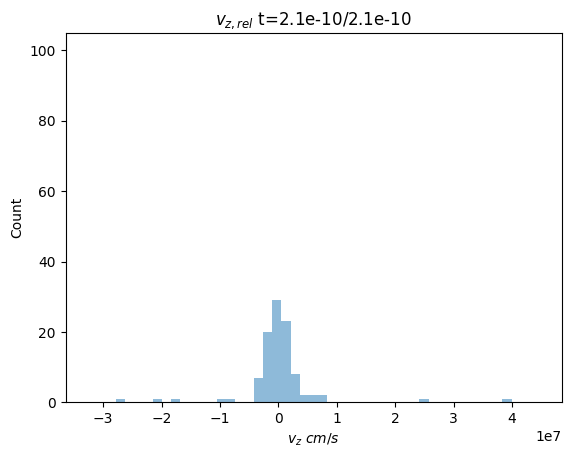

In [12]:

import functools

import matplotlib.pyplot as plt
import numpy as np

import matplotlib.animation as animation

# Setting up a random number generator with a fixed state for reproducibility.
# Fixing bin edges.
HIST_BINS = np.linspace(np.min(res), np.max(res), 50)

# Histogram our data with numpy.
data = res[0,:]
n, _ = np.histogram(data, HIST_BINS)


frametoi = np.arange(0,len(timearr),10)
fig, ax = plt.subplots()
_, _, bar_container = ax.hist(data, HIST_BINS, lw=1,
                              ec="yellow", fc="green", alpha=0.5)
def animate(frame_number, bar_container):
    ax.set_title(r"$v_{{z,rel}}$ t={:.1e}/{:.1e}".format(timearr[frametoi[frame_number]],timearr[-1]))
    ax.set_xlabel(r"$v_z$ $cm/s$")
    ax.set_ylabel("Count")
    # Simulate new data coming in.
    data = res[frametoi[frame_number],:]
    n, _ = np.histogram(data, HIST_BINS)
    for count, rect in zip(n, bar_container.patches):
        rect.set_height(count)

    return bar_container.patches

anim = functools.partial(animate, bar_container=bar_container)
ani = animation.FuncAnimation(fig, anim, len(frametoi), repeat=False, blit=True)
ani.save("animz.gif",fps=40)
plt.show()

MovieWriter ffmpeg unavailable; using Pillow instead.


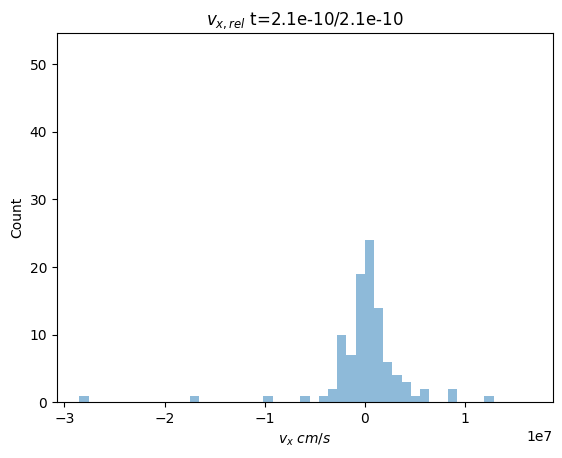

In [13]:

import functools

import matplotlib.pyplot as plt
import numpy as np

import matplotlib.animation as animation

# Setting up a random number generator with a fixed state for reproducibility.
# Fixing bin edges.
HIST_BINS = np.linspace(np.min(resx), np.max(resx), 50)

# Histogram our data with numpy.
data = resx[0,:]
n, _ = np.histogram(data, HIST_BINS)


frametoi = np.arange(0,len(timearr),10)
fig, ax = plt.subplots()
_, _, bar_container = ax.hist(data, HIST_BINS, lw=1,
                              ec="yellow", fc="green", alpha=0.5)
def animate(frame_number, bar_container):
    ax.set_title(r"$v_{{x,rel}}$ t={:.1e}/{:.1e}".format(timearr[frametoi[frame_number]],timearr[-1]))
    ax.set_xlabel(r"$v_x$ $cm/s$")
    ax.set_ylabel("Count")
    # Simulate new data coming in.
    data = resx[frametoi[frame_number],:]
    n, _ = np.histogram(data, HIST_BINS)
    for count, rect in zip(n, bar_container.patches):
        rect.set_height(count)

    return bar_container.patches

anim = functools.partial(animate, bar_container=bar_container)
ani = animation.FuncAnimation(fig, anim, len(frametoi), repeat=False, blit=True)
ani.save("animx.gif",fps=40)
plt.show()

MovieWriter ffmpeg unavailable; using Pillow instead.


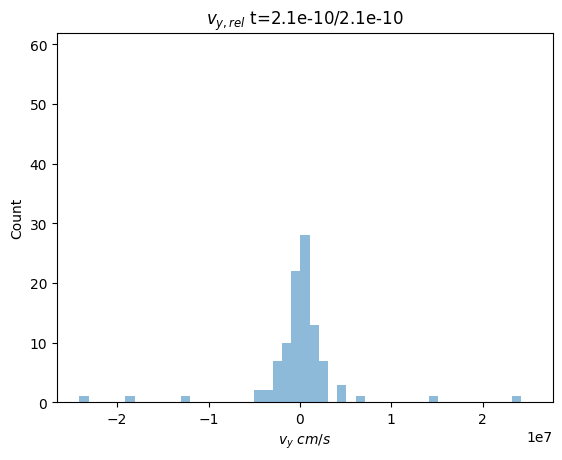

In [43]:

import functools

import matplotlib.pyplot as plt
import numpy as np

import matplotlib.animation as animation

# Setting up a random number generator with a fixed state for reproducibility.
# Fixing bin edges.
HIST_BINS = np.linspace(np.min(resy), np.max(resy), 50)

# Histogram our data with numpy.
data = resy[0,:]
n, _ = np.histogram(data, HIST_BINS)


frametoi = np.arange(0,len(timearr),10)
fig, ax = plt.subplots()
_, _, bar_container = ax.hist(data, HIST_BINS, lw=1,
                              ec="yellow", fc="green", alpha=0.5)
def animate(frame_number, bar_container):
    ax.set_title(r"$v_{{y,rel}}$ t={:.1e}/{:.1e}".format(timearr[frametoi[frame_number]],timearr[-1]))
    ax.set_xlabel(r"$v_y$ $cm/s$")
    ax.set_ylabel("Count")
    # Simulate new data coming in.
    data = resy[frametoi[frame_number],:]
    n, _ = np.histogram(data, HIST_BINS)
    for count, rect in zip(n, bar_container.patches):
        rect.set_height(count)

    return bar_container.patches

anim = functools.partial(animate, bar_container=bar_container)
ani = animation.FuncAnimation(fig, anim, len(frametoi), repeat=False, blit=True)
ani.save("animy.gif",fps=40)
plt.show()

MovieWriter ffmpeg unavailable; using Pillow instead.
C:\Users\shaoq\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\scipy\optimize\_minpack_py.py:497: RuntimeWarning: overflow encountered in matmul
  cov_x = invR @ invR.T


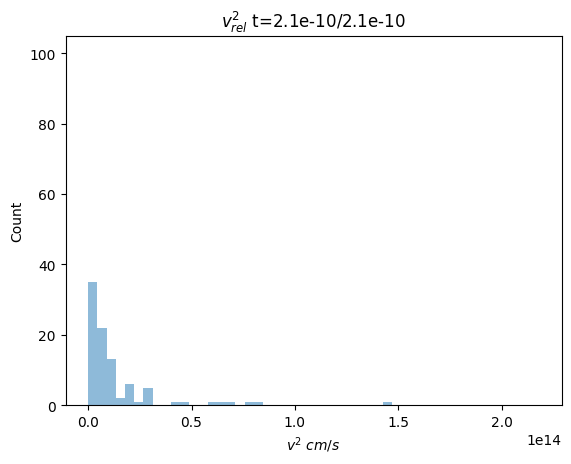

In [42]:

import functools

import matplotlib.pyplot as plt
import numpy as np

import matplotlib.animation as animation
#Maxwellian speed dist

# Setting up a random number generator with a fixed state for reproducibility.
# Fixing bin edges.
v2 = np.square(resx) + np.square(res) + np.square(resy)
HIST_BINS = np.linspace(np.min(v2), np.max(v2)/10, 50)

# Histogram our data with numpy.
data = v2[0,:]
n, _ = np.histogram(data, HIST_BINS)
binmid = np.zeros(len(n))
for i in range(len(n)):
    binmid[i] = (HIST_BINS[i+1]+HIST_BINS[i])/2

mSi = 0.0280855/NA
pi=3.14159
bestfit,pcov = curve_fit(lambda vsq,T: 100*4*pi*((mSi/(2*pi*kb*T))**1.5)*np.exp(-vsq*mSi/(2*kb*T*10000)),  binmid,  n,  p0=(10000))
bestT = bestfit[0]
aerr = np.sqrt(np.diag(pcov))[0]


frametoi = np.arange(0,len(timearr),10)
fig, ax = plt.subplots()
_, _, bar_container = ax.hist(data, HIST_BINS, lw=1,
                              ec="yellow", fc="green", alpha=0.5)

MBdist = 100*4*pi*((mSi/(2*pi*kb*bestT))**1.5)*np.exp(-HIST_BINS*mSi/(2*kb*bestT*10000))
# ax.plot(HIST_BINS,MBdist,label="Maxwell Boltzmann T={}".format(bestT))
# ax.legend()
def animate(frame_number, bar_container):
    ax.set_title(r"$v^2_{{rel}}$ t={:.1e}/{:.1e}".format(timearr[frametoi[frame_number]],timearr[-1]))
    ax.set_xlabel(r"$v^2$ $cm/s$")
    ax.set_ylabel("Count")
  # Simulate new data coming in.
    data = v2[frametoi[frame_number],:]
    n, _ = np.histogram(data, HIST_BINS)
    for count, rect in zip(n, bar_container.patches):
        rect.set_height(count)
    bestfit,pcov = curve_fit(lambda vsq,T: 100*4*pi*((mSi/(2*pi*kb*T))**1.5)*np.exp(-vsq*mSi/(2*kb*T*10000)),  binmid,  n,  p0=(10000))
    bestT = bestfit[0]
    # ax.plot(HIST_BINS,MBdist,label="Maxwell Boltzmann T={}".format(bestT))
    # ax.legend()  
    return bar_container.patches

anim = functools.partial(animate, bar_container=bar_container)
ani = animation.FuncAnimation(fig, anim, len(frametoi), repeat=False, blit=True)
ani.save("animv2.gif",fps=40)
plt.show()